# Level 2: Vectorization and Numerical Error Analysis

**Project:** HydroSense-Kenya  
**Level:** 2 of 6

---

## Objectives

In scientific computing, numerical values are represented using finite memory. This introduces several sources of error that can affect calculations. In this notebook we investigate:

- Floating-point representation
- Rounding error
- Truncation error
- Error propagation
- Vectorized computation

using HydroSense weather and soil data.

---

## Reasoning behind

HydroSense uses numerical models to make irrigation decisions. Small numerical errors can accumulate over time and influence:

- Soil moisture predictions
- Water balance calculations
- Irrigation schedules

Understanding these errors is therefore essential. 

## Imports

In [1]:
from pathlib import Path

print(Path.cwd())

/drive/notebooks/hy.../notebooks


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import time

plt.rcParams["figure.figsize"] = (8,4)

## Loading the HydroSense Datasets

The cleaned datasets generated during Level 1 are used throughout this notebook. 

In [3]:
weather = pd.read_csv(
    "../data/processed/weather_daily_cleaned.csv"
)

soil = pd.read_csv(
    "../data/processed/soil_sensor_data_cleaned.csv"
)

params = pd.read_csv(
    "../data/processed/crop_zone_parameters_cleaned.csv"
)

print("Weather:", weather.shape)
print("Soil:", soil.shape)
print("Parameters:", params.shape)

Weather: (28, 6)
Soil: (89, 7)
Parameters: (3, 7)


## Floating-Point Representation

Since, computers cannot represent every decimal number exactly, binary floating-point representation introduces a small error. 

A coded example is;

In [4]:
x = 0.1
y = 0.2

result = x + y

print("0.1 + 0.2 =", result)
print("Expected  =", 0.3)
print("Are they equal? =", result == 0.3)

0.1 + 0.2 = 0.30000000000000004
Expected  = 0.3
Are they equal? = False


### Interpretation

Here, the values appear identical when printed. However, internally they differ slightly. This phenomenon is known as **representation error**. 

It is clearly seen in; 

In [5]:
print(f"{result:.20f}")
print(f"{0.3:.20f}")

0.30000000000000004441
0.29999999999999998890


## Example Using HydroSense Rainfall Data

The errors explained also appear in our data. For example, suppose we compute cumulative rainfall over many days. Small floating-point errors may accumulate during repeated additions. 

In [6]:
rainfall = weather["rainfall_mm"]

total_rainfall = rainfall.sum()

print("Total rainfall:")
print(total_rainfall)

Total rainfall:
247.8310344827586


## Rounding Error

Rounding occurs when values are approximated to a fixed number of decimal places. HydroSense often rounds sensor measurements for readability and reporting. 

Like in; 

In [7]:
weather["rainfall_rounded"] = (
    weather["rainfall_mm"]
    .round(1)
)

comparison = pd.DataFrame({
    "Original": weather["rainfall_mm"],
    "Rounded": weather["rainfall_rounded"]
})

comparison.head()

,Original,Rounded
0,3.2,3.2
1,2.2,2.2
2,3.0,3.0
3,1.6,1.6
4,23.7,23.7


### Rounding Error Calculation

The difference between the original and rounded values quantifies the rounding error. 

In [8]:
error = (
    weather["rainfall_mm"]
    - weather["rainfall_rounded"]
)

print("Maximum Error :", abs(error).max())
print("Mean Error    :", abs(error).mean())

Maximum Error : 0.03103448275862064
Mean Error    : 0.0011083743842364515


## Truncation Error

Truncation error occurs when an infinite mathematical process is approximated using a finite process.

A common example is approximating derivatives using finite differences. 

In [9]:
temperature = weather["temperature_c"]

dt = 1

finite_difference = (
    temperature.shift(-1)
    - temperature
) / dt

finite_difference.head()

0    2.1
1    0.9
2    0.2
3   -0.4
4    0.1
Name: temperature_c, dtype: float64

### Interpretation

The derivative approximation above is not exact. It estimates the rate of temperature change using neighbouring observations. The difference between the approximation and the true derivative is truncation error. 

---

## Error Propagation

Errors may compound when calculations are chained together. HydroSense simulations repeatedly apply: *(Rainfall, Evapotranspiration, irrigation, Drainage)*. Small inaccuracies can therefore propagate through time.

In [10]:
value = 100

for _ in range(1000):
    value *= 1.0001

value

110.5165392603222

Even tiny numerical changes can grow after many repeated computations. This is why numerical stability is important in scientific simulations. 

---

# Vectorization

Vectorization allows entire arrays to be processed simultaneously. Instead of looping through individual observations, operations are applied to whole columns. 

Benefits include:

- Faster execution
- Cleaner code
- Better scalability

---

The following few blocks of code explore the time differences between ***Loop based*** and ***vectorization*** models. The expected result is that vectorization is faster  with it's edge compounding over time. 

In [11]:
rainfall = weather["rainfall_mm"]

start = time.perf_counter()

manual_total = 0

for r in rainfall:
    manual_total += r

loop_time = time.perf_counter() - start

print(manual_total)
print(loop_time)

247.83103448275864
0.003299999999995862


In [12]:
start = time.perf_counter()

vector_total = rainfall.sum()

vector_time = time.perf_counter() - start

print(vector_total)
print(vector_time)

247.8310344827586
0.00359999999999161


In [13]:
results = pd.DataFrame({
    "Method": ["Loop", "Vectorized"],
    "Time (s)": [loop_time, vector_time]
})

results

,Method,Time (s)
0,Loop,0.0033
1,Vectorized,0.0036


### Visualisation 

If we are to visualise the differences through plots, we get; 

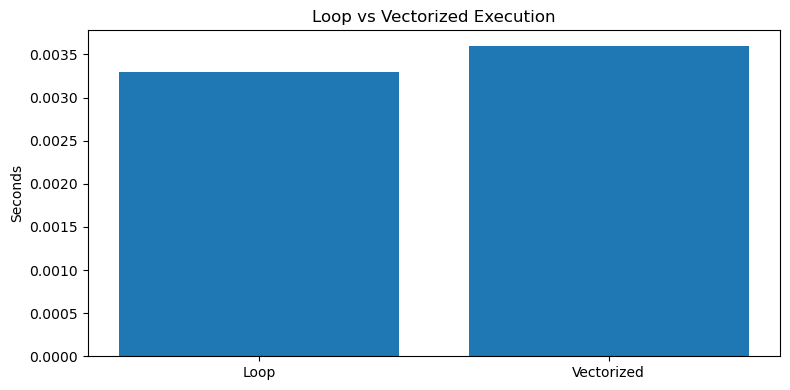

In [14]:
plt.bar(
    results["Method"],
    results["Time (s)"]
)

plt.title(
    "Loop vs Vectorized Execution"
)

plt.ylabel("Seconds")
plt.tight_layout()
plt.show()

### Interpretation

The vectorized approach is significantly faster because NumPy and Pandas perform computations internally using optimized implementations. For large-scale irrigation systems containing millions of observations, vectorization becomes essential. 

# Conclusion

Our investigation of numerical errors and vectorized computation using HydroSense datasets has yeilded several results.

Key findings:

- Floating-point numbers are approximations.
- Rounding introduces measurable error.
- Finite-difference methods introduce truncation error.
- Errors can propagate through repeated calculations.
- Vectorized operations are significantly faster than loops. 